# Super Store Sales Analysis

## Setup

### Set up Environment

In [82]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data loading and cleaning

### Load and Inspect

In [83]:
df_train = pd.read_csv("../data/train.csv", encoding = "latin1")
df_super_store = pd.read_csv("../data/SampleSuperstore.csv", encoding = "latin1")

common_cols = ["Ship Mode", "Segment", "Country", "City", "State", "Postal Code", "Region", "Category", "Sub-Category", "Sales"]

df_master = pd.merge(df_train, df_super_store[common_cols + ["Quantity", "Discount", "Profit"]], on = common_cols, how = "left")
print(df_master.head())

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688  12/06/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0     42420.0   Sout

In [84]:
df_master.info()

<class 'pandas.DataFrame'>
RangeIndex: 9846 entries, 0 to 9845
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9846 non-null   int64  
 1   Order ID       9846 non-null   str    
 2   Order Date     9846 non-null   str    
 3   Ship Date      9846 non-null   str    
 4   Ship Mode      9846 non-null   str    
 5   Customer ID    9846 non-null   str    
 6   Customer Name  9846 non-null   str    
 7   Segment        9846 non-null   str    
 8   Country        9846 non-null   str    
 9   City           9846 non-null   str    
 10  State          9846 non-null   str    
 11  Postal Code    9835 non-null   float64
 12  Region         9846 non-null   str    
 13  Product ID     9846 non-null   str    
 14  Category       9846 non-null   str    
 15  Sub-Category   9846 non-null   str    
 16  Product Name   9846 non-null   str    
 17  Sales          9846 non-null   float64
 18  Quantity       9835

In [85]:
df_master.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9846.000000,9835.000000,9846.000000,9835.000000,9835.000000,9835.000000
mean,4901.153260,55320.557092,229.977340,3.786985,0.156708,28.192512
std,2828.302535,32052.283897,625.329776,2.215939,0.206786,235.326727
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2455.250000,23223.000000,17.142500,2.000000,0.000000,1.719300
50%,4900.500000,59405.000000,53.946000,3.000000,0.200000,8.526000
75%,7350.750000,90008.000000,209.976750,5.000000,0.200000,29.085000
max,9800.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


### Fix Data Types

In [86]:
df_master["Order Date"] = pd.to_datetime(df_master["Order Date"], format = "%d/%m/%Y")
print(f"Datatype of Order Date Column: {df_master["Order Date"].dtype}")

df_master["Ship Date"] = pd.to_datetime(df_master["Ship Date"], format = "%d/%m/%Y")
print(f"Datatype of Ship Date Column: {df_master["Ship Date"].dtype}")

Datatype of Order Date Column: datetime64[us]
Datatype of Ship Date Column: datetime64[us]


In [87]:
df_master[df_master["Profit"].isnull()]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
2241,2235,CA-2018-104066,2018-12-05,2018-12-10,Standard Class,QJ-19255,Quincy Jones,Corporate,United States,Burlington,...,NaN,East,TEC-AC-10001013,Technology,Accessories,Logitech ClearChat Comfort/USB Headset H390,205.03,NaN,NaN,NaN
5298,5275,CA-2016-162887,2016-11-07,2016-11-09,Second Class,SV-20785,Stewart Visinsky,Consumer,United States,Burlington,...,NaN,East,FUR-CH-10000595,Furniture,Chairs,Safco Contoured Stacking Chairs,715.20,NaN,NaN,NaN
8840,8799,US-2017-150140,2017-04-06,2017-04-10,Standard Class,VM-21685,Valerie Mitchum,Home Office,United States,Burlington,...,NaN,East,TEC-PH-10002555,Technology,Phones,Nortel Meridian M5316 Digital phone,1294.75,NaN,NaN,NaN
9188,9147,US-2017-165505,2017-01-23,2017-01-27,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,...,NaN,East,TEC-AC-10002926,Technology,Accessories,Logitech Wireless Marathon Mouse M705,99.98,NaN,NaN,NaN
9189,9148,US-2017-165505,2017-01-23,2017-01-27,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,...,NaN,East,OFF-AR-10003477,Office Supplies,Art,4009 Highlighters,8.04,NaN,NaN,NaN
9190,9149,US-2017-165505,2017-01-23,2017-01-27,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,...,NaN,East,OFF-ST-10001526,Office Supplies,Storage,Iceberg Mobile Mega Data/Printer Cart,1564.29,NaN,NaN,NaN
9430,9387,US-2018-127292,2018-01-19,2018-01-23,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,...,NaN,East,OFF-PA-10000157,Office Supplies,Paper,Xerox 191,79.92,NaN,NaN,NaN
9431,9388,US-2018-127292,2018-01-19,2018-01-23,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,...,NaN,East,OFF-PA-10001970,Office Supplies,Paper,Xerox 1881,12.28,NaN,NaN,NaN
9432,9389,US-2018-127292,2018-01-19,2018-01-23,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,...,NaN,East,OFF-AP-10000828,Office Supplies,Appliances,Avanti 4.4 Cu. Ft. Refrigerator,542.94,NaN,NaN,NaN
9433,9390,US-2018-127292,2018-01-19,2018-01-23,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,...,NaN,East,OFF-EN-10001509,Office Supplies,Envelopes,Poly String Tie Envelopes,2.04,NaN,NaN,NaN


### Handle Missing and Duplicates

In [88]:
null_count_super_store = df_master.isnull().sum()
print("null in super store:", null_count_super_store)

df_master.dropna(subset = ["Profit"], inplace = True)

null_count_super_store_2 = df_master.isnull().sum()
print("null in super store 2:", null_count_super_store_2)

duplicates_super_store = df_master.duplicated()
print("duplicates in super store:", duplicates_super_store) # no duplicates

df_master.drop_duplicates(inplace=True)
print("Info: ", df_master.info()) # no duplicates

null in super store: Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity         11
Discount         11
Profit           11
dtype: int64
null in super store 2: Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64
duplicates in super store: 0       False
1       False
2       False
3       False
4       False
        ...  


### Feature Engineering

In [89]:
df_master["Month"] = df_master["Order Date"].dt.to_period("M")
df_master["Year"] = df_master["Order Date"].dt.year
df_master["Profit Margin(%)"] = df_master["Profit"] / df_master["Sales"] * 100

print(df_master.shape)

(9801, 24)


## Core analysis

### Monthly Revenue

In [90]:
monthly_revenue = (
    df_master
    .groupby("Month")["Sales"]
    .sum()
    .reset_index()
    .rename(columns = {"Sales": "Monthly Revenue"})
)
monthly_revenue.head()

,Month,Monthly Revenue
0,2015-01,14205.707
1,2015-02,4519.892
2,2015-03,55205.797
3,2015-04,27952.775
4,2015-05,23657.695


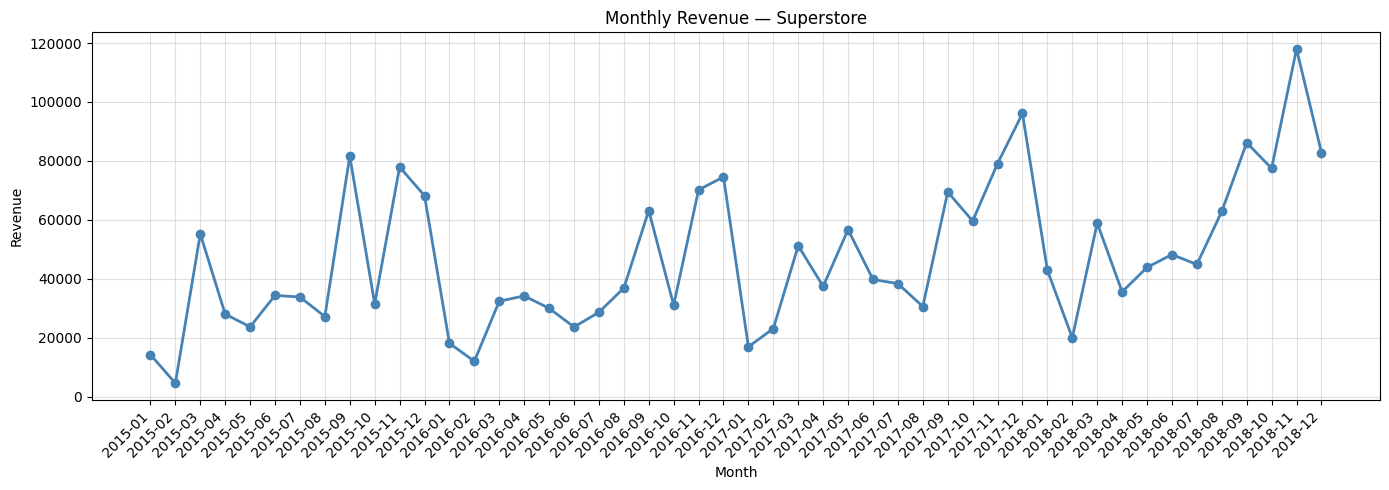

In [123]:
sorted_month = (
    monthly_revenue
    .assign(month_year_str = monthly_revenue["Month"].astype(str))
    .sort_values("month_year_str")
)

plt.figure(figsize=(14, 5))
plt.plot(sorted_month["month_year_str"], sorted_month["Monthly Revenue"], marker='o', linewidth=2, color='steelblue')
plt.grid(axis='x', alpha=0.4)
plt.title("Monthly Revenue — Superstore")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig("monthly_revenue.png", dpi=150)
plt.show()

**Insight:** I am seeing one pattern in this Monthly Revenue line chart that Super store earns majority of their revenue in the last 4 months of the every year because line is always rising to the peak at the September of the year, down in October but again rising to the peak in peaks in November and December.

### Top Products

In [92]:
df_master.head()
top_products = (
    df_master.groupby("Product Name")["Sales"]
    .sum()
    .reset_index()
    .rename(columns = {"Sales": "Total Product Sales"})
    .sort_values("Total Product Sales", ascending = False)
)
top_products.head(10)

,Product Name,Total Product Sales
403,Canon imageCLASS 2200 Advanced Copier,61599.824
648,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.384
443,Cisco TelePresence System EX90 Videoconferenci...,22638.480
784,HON 5400 Series Task Chairs for Big and Tall,21870.576
684,GBC DocuBind TL300 Electric Binding System,19823.479
686,GBC Ibimaster 500 Manual ProClick Binding System,19024.500
803,Hewlett Packard LaserJet 3310 Copier,18839.686
785,HP Designjet T520 Inkjet Large Format Printer ...,18374.895
681,GBC DocuBind P400 Electric Binding System,17965.068
811,High Speed Automatic Electric Letter Opener,17030.312


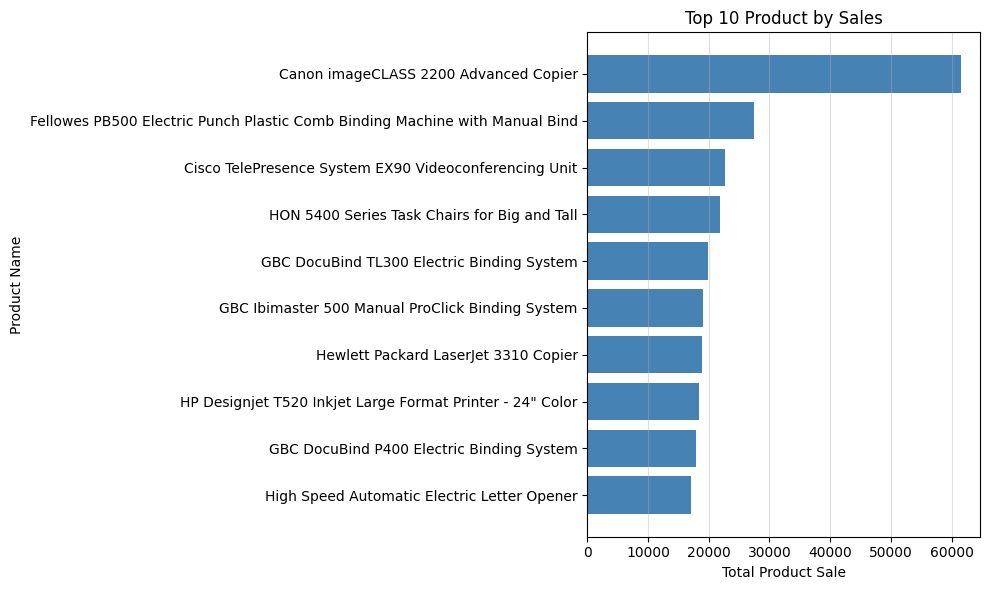

In [ ]:
top_10_products = top_products.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_10_products["Product Name"], top_10_products["Total Product Sales"], color='steelblue')
plt.grid(axis='x', alpha=0.4)
plt.xlabel("Total Product Sale")
plt.ylabel("Product Name")
plt.title("Top 10 Product by Sales")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("product_by_sale_count.png", dpi=150)
plt.show()

**Insight:** Canon imageCLASS 2200 Advanced Copier is clearly dominating Product in sales with 60,000+ sales and on the other hand, other products from top 10 are stay between 15,000 to 30,000 sales. so we can say that rest products are far lower than Canon imageCLASS 2200 Advanced Copier.

### Profit Analysis

In [94]:
region_profit = (
    df_master
    .groupby("Region")[["Sales", "Profit"]]
    .sum()
    .reset_index()
)
region_profit["Profit Margin(%)"] = (region_profit["Profit"] / region_profit["Sales"] * 100).round(2)
print(region_profit.sort_values("Profit Margin(%)", ascending = False))

    Region        Sales       Profit  Profit Margin(%)
3     West  710219.6845  105357.2069             14.83
1     East  660795.2160   87338.1538             13.22
2    South  389697.2790   46384.9713             11.90
0  Central  492704.8012   37881.8299              7.69


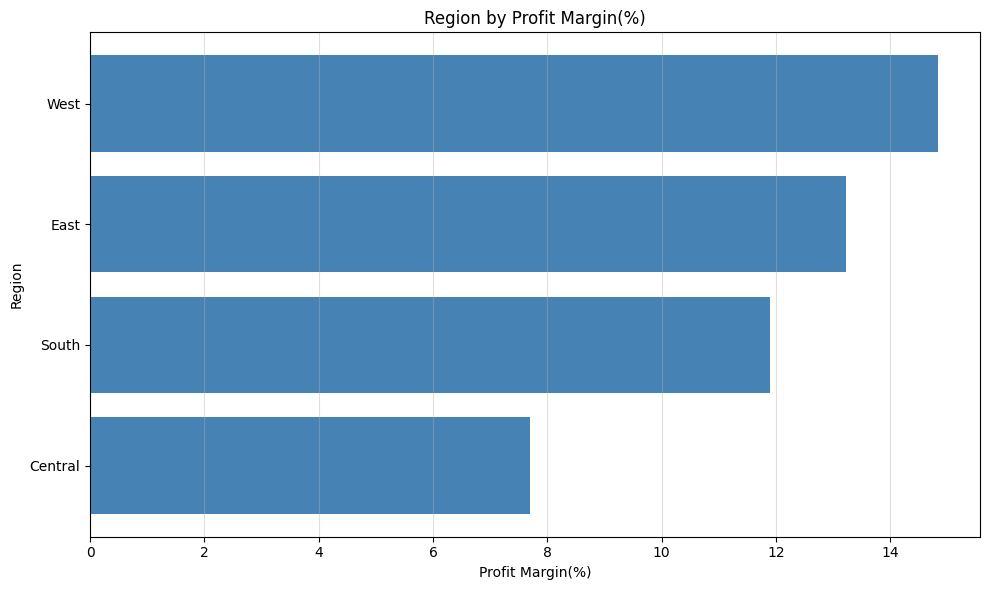

In [120]:
sorted_region_profit = region_profit.sort_values("Profit Margin(%)", ascending = False)

plt.figure(figsize=(10, 6))
plt.barh(sorted_region_profit["Region"], sorted_region_profit["Profit Margin(%)"], color='steelblue')
plt.grid(axis='x', alpha=0.4)
plt.xlabel("Profit Margin(%)")
plt.ylabel("Region")
plt.title("Region by Profit Margin(%)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("region_profit.png", dpi=150)
plt.show()

**Insight:** Region wise profit margin is highest in West part(14.85%) but other's is also significantly profitable for superstore.

In [96]:
category_profit = (
    df_master
    .groupby("Category")[["Sales", "Profit"]]
    .sum()
    .reset_index()
)
category_profit["Profit Margin(%)"] = (category_profit["Profit"] / category_profit["Sales"] * 100).round(2)
print(category_profit.sort_values("Profit Margin(%)", ascending = False))

          Category        Sales       Profit  Profit Margin(%)
2       Technology  826535.9530  142839.2092             17.28
1  Office Supplies  703342.5520  118393.1955             16.83
0        Furniture  723538.4757   15729.7572              2.17


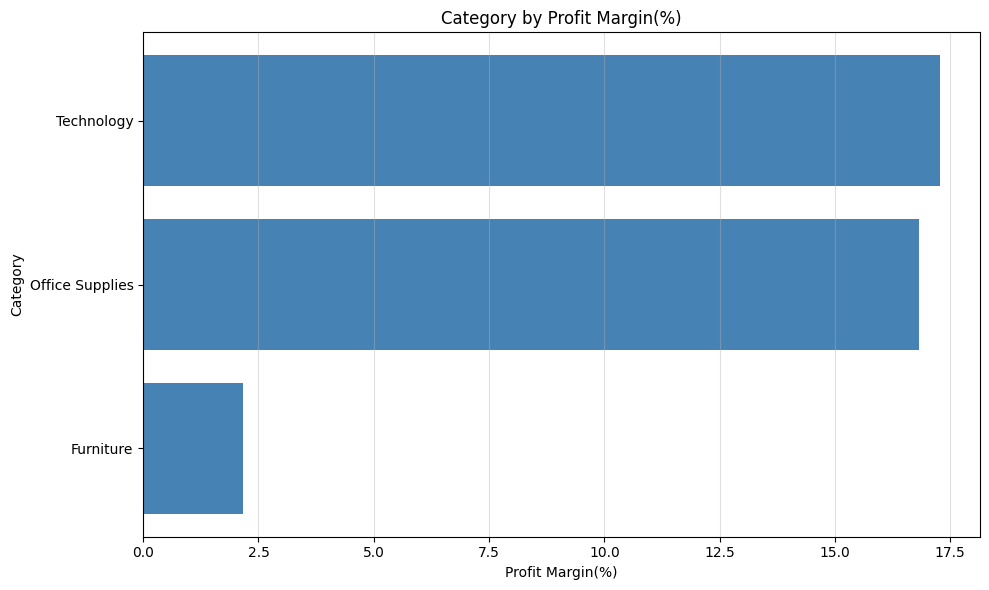

In [119]:
sorted_category_profit = category_profit.sort_values("Profit Margin(%)", ascending = False)

plt.figure(figsize=(10, 6))
plt.barh(sorted_category_profit["Category"], sorted_category_profit["Profit Margin(%)"], color='steelblue')
plt.grid(axis='x', alpha=0.4)
plt.xlabel("Profit Margin(%)")
plt.ylabel("Category")
plt.title("Category by Profit Margin(%)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("category_profit.png", dpi=150)
plt.show()

**Insight:** Category wise profit margin is showing that Furniture has very negligible profit margin(2.18%) as compare to other two category like Technology(17.28%) and Office Supplies(16.85%).

In [98]:
segment_profit = (
    df_master
    .groupby("Segment")[["Sales", "Profit"]]
    .sum()
    .reset_index()
)
segment_profit["Profit Margin(%)"] = (segment_profit["Profit"] / segment_profit["Sales"] * 100).round(2)
print(segment_profit.sort_values("Profit Margin(%)", ascending = False))

       Segment         Sales       Profit  Profit Margin(%)
2  Home Office  4.236874e+05   59401.4504             14.02
1    Corporate  6.822889e+05   86609.5014             12.69
0     Consumer  1.147441e+06  130951.2101             11.41


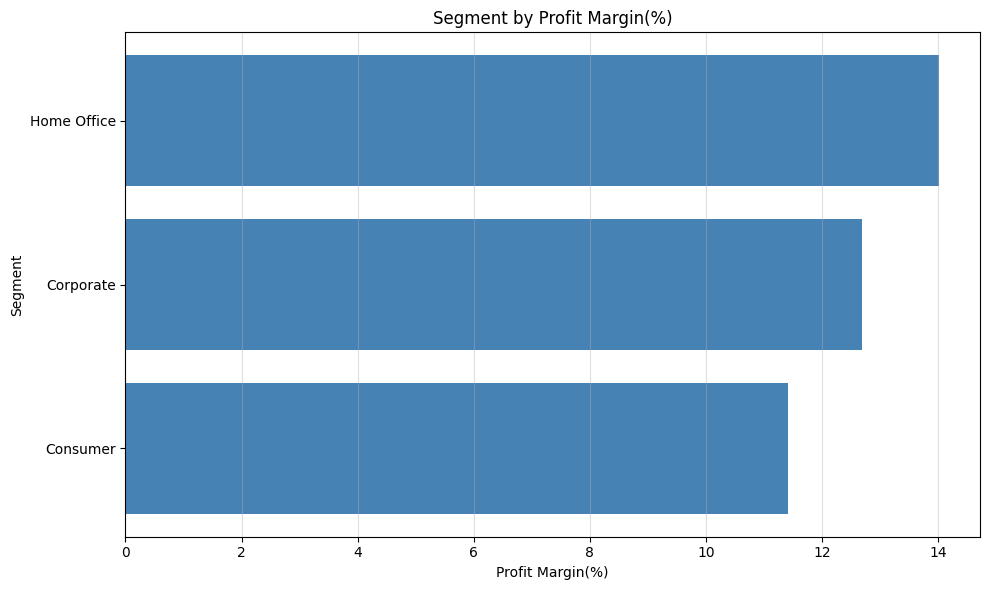

In [118]:
sorted_segment_profit = segment_profit.sort_values("Profit Margin(%)", ascending = False)

plt.figure(figsize=(10, 6))
plt.barh(sorted_segment_profit["Segment"], sorted_segment_profit["Profit Margin(%)"], color='steelblue')
plt.grid(axis='x', alpha=0.4)
plt.xlabel("Profit Margin(%)")
plt.ylabel("Segment")
plt.title("Segment by Profit Margin(%)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("segment_profit.png", dpi=150)
plt.show()

**Insight:** Home Office(14.01%) is tops in profit margin followed by Corporate(12.70%) and Consumer(11.42%). Here every Segment is very close in profit margin.

In [100]:
pivot1 = df_master.pivot_table(values = "Profit", index = "Region", columns = "Category", aggfunc = "sum")
pivot2 = df_master.pivot_table(values = "Profit", index = "Region", columns = "Segment", aggfunc = "sum")

print("pivot table - 1:")
print(pivot1)
print("pivot table - 2:")
print(pivot2)

pivot table - 1:
Category   Furniture  Office Supplies  Technology
Region                                           
Central   -3281.0099        7918.3789  33244.4609
East       1766.2765       38842.5809  46729.2964
South      6662.2732       19789.2152  19933.4829
West      10582.2174       51843.0205  42931.9690
pivot table - 2:
Segment    Consumer   Corporate  Home Office
Region                                      
Central   8254.7606  17255.9401   12371.1292
East     40037.2259  20913.9298   26386.9981
South    26861.4195  14991.9785    4531.5733
West     55797.8041  33447.6530   16111.7498


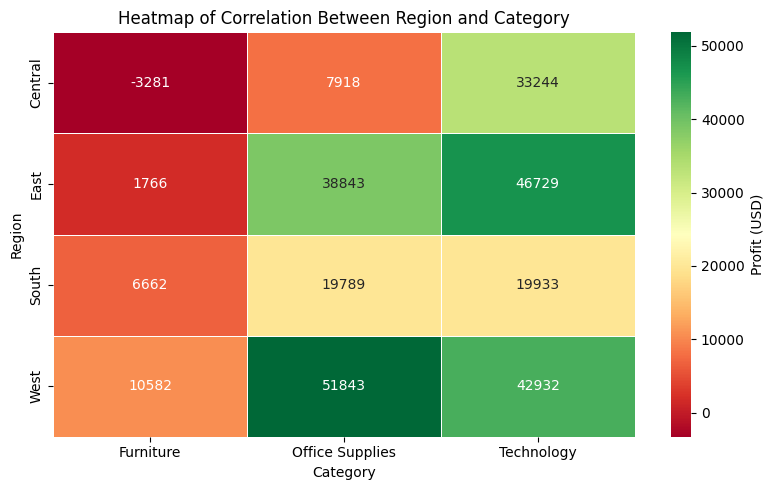

In [101]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot1, annot = True, fmt = ".0f", cmap = "RdYlGn",linewidths = 0.5, ax = ax, cbar_kws = {"label": "Profit (USD)"})
plt.title("Heatmap of Correlation Between Region and Category")
plt.xlabel("Category")
plt.ylabel("Region")
plt.tight_layout()
plt.savefig("Heatmap_pivot1.png")
plt.show()

**Insight:** like we already see that Furniture and Central have very low profit margin now we also can see same thing that in this heatmap where all orange to red box are in Furniture Category and Central Region. and It also one of box where It contains loss also(-3211). and 2nd thing is also we can see that Office Supplies ad Technolgy are highly profitable. and at last I want to say that Except Central region, Every other regions like West, South and East are almost equally profitable.
Highest Profit - Office Supplies and West
Lowest Profit - Furniture and Central (we also can that as loss because It is negative profit.)

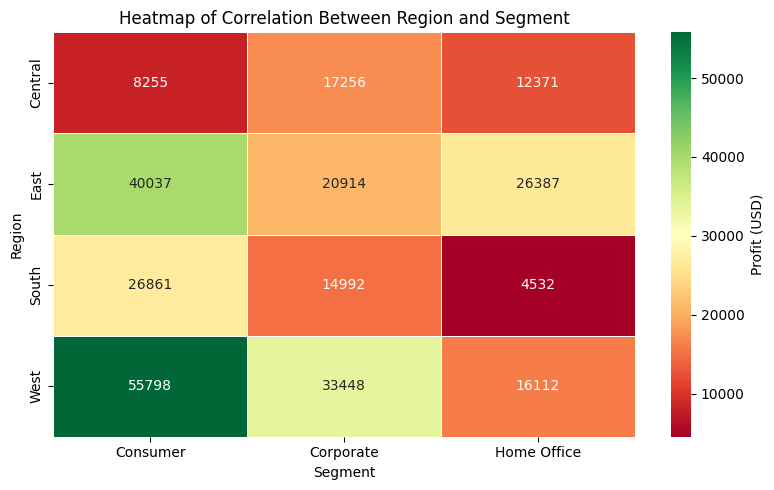

In [108]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot2, annot = True, fmt = ".0f", cmap = "RdYlGn",linewidths = 0.5, ax = ax, cbar_kws = {"label": "Profit (USD)"})
plt.title("Heatmap of Correlation Between Region and Segment")
plt.xlabel("Segment")
plt.ylabel("Region")
plt.tight_layout()
plt.savefig("Heatmap_pivot2.png", dpi = 150)
plt.show()

**Insight:** like we already see in previous heatmap, here also central region contains lowest profit margin but south region does not have that much profit therefore East and West are carried profit in region wise. In Segment, Consumer is carring profit despite low profit margin(%). other segment has low profit but have high profit margin(%) so all are good enough in contribution in Superstore.
Highest profit - Consumer and West
Lowest profit - Home Office and South

### discount vs profit

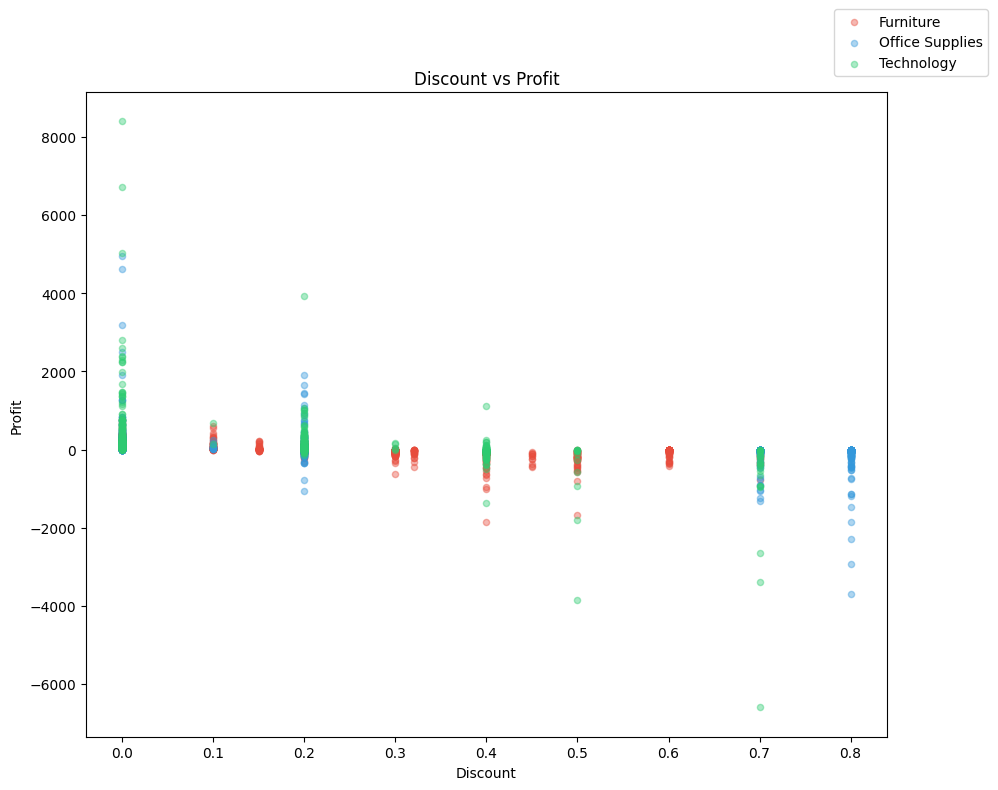

In [117]:
fig, ax = plt.subplots(figsize=(10, 8))

ax.set_xlabel("Discount")
ax.set_ylabel("Profit")
ax.set_title("Discount vs Profit")
colors_cat = {'Furniture': '#e74c3c', 'Office Supplies': '#3498db', 'Technology': '#2ecc71'}
for cat, group in df_master.groupby('Category'):
    ax.scatter(group['Discount'], group['Profit'], alpha = 0.4, s = 20, label = cat, color = colors_cat[cat])
ax.legend(bbox_to_anchor = (1,0.89), loc = "lower right",  bbox_transform = fig.transFigure)

plt.tight_layout()
plt.savefig("discount_vs_profit.png", dpi = 150)
plt.show()

**Insight:** Looking at the scatter plot there are a few main takeaways. First, there's a really clear negative trend—basically, as the discount goes up the profits drop pretty sharply. The tipping point seems to be right around the 0.2 (20%) discount mark. If we keep discounts at 0.2 or lower, we're mostly still making money. But once the discounts hit 0.3 (30%) or higher, almost every transaction turns into a net loss.

## Key Business Takeaways

Based on the exploratory data analysis of the Superstore dataset, we have identified several clear opportunities to optimize profitability and operational efficiency:

Implement a Strict 20% Discount Cap: The most critical finding is the definitive profit tipping point regarding discounts. Transactions with discounts exceeding 20% consistently result in net losses. Management should immediately cap standard promotional discounts at 20% and restrict deeper cuts exclusively to clearing dead stock.

Investigate or Restructure the Central Region's Furniture Line: The Furniture category in the Central region is actively losing money (net negative profit). The business needs to audit shipping costs, supplier pricing, and overhead for furniture in this specific region. If margins cannot be improved, consider reducing the furniture catalog in the Central area to focus on higher-margin goods.

Capitalize on Q4 Seasonality: The revenue trend shows massive spikes in months 9, 11, and 12. Marketing budgets, inventory acquisition, and warehouse staffing should be heavily weighted toward the end of Q3 to fully capture the peak holiday and end-of-year corporate buying seasons.

Prioritize Office Supplies and Technology: These two categories drive the vast majority of the company's profit, particularly in the West and East regions. Marketing campaigns and premium shelf space (both digital and physical) should prioritize these high-margin items over low-margin bulk goods.

Leverage High-Volume Staple Products: While "Staples" and "Staple Envelopes" have the highest sales volume, they likely have lower individual margins. These items should be used as "loss leaders" or add-on items at checkout to drive up the total cart size of highly profitable Technology or Office Supply orders.